In [10]:
import pandas as pd
pd.set_option("display.max_columns", None)

In [11]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

adult = pd.read_csv(
    r"E:\DSDA\CensusDataset\adult.data",
    header=None,
    names=columns,
    skipinitialspace=True
)

In [12]:
adult_test = pd.read_csv(
    r"E:\DSDA\CensusDataset\adult.test",
    header=None,
    names=columns,
    skipinitialspace=True,
    comment="|"
)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Clean up missing values marked as "?"
adult_clean = adult.replace("?", pd.NA).dropna()


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Clean up missing values marked as "?"
adult_clean = adult.replace("?", pd.NA).dropna()

# Target: convert income to binary (0 = <=50K, 1 = >50K)
adult_clean["income"] = adult_clean["income"].str.strip()
y = (adult_clean["income"] == ">50K").astype(int)

# Features: one-hot encode categoricals, drop original income column
X = pd.get_dummies(adult_clean.drop(columns=["income"]), drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=10, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

print("--- Random Forest: Train ---")
print("Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Precision:", precision_score(y_train, y_train_pred_rf))
print("Recall:", recall_score(y_train, y_train_pred_rf))
print("F1-score:", f1_score(y_train, y_train_pred_rf))

print("\n--- Random Forest: Test ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("Precision:", precision_score(y_test, y_test_pred_rf))
print("Recall:", recall_score(y_test, y_test_pred_rf))
print("F1-score:", f1_score(y_test, y_test_pred_rf))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_rf))

--- Random Forest: Train ---
Accuracy: 0.914169671349828
Precision: 0.9016125739946927
Recall: 0.7354312354312355
F1-score: 0.810087116001834

--- Random Forest: Test ---
Accuracy: 0.858942483010111
Precision: 0.7847769028871391
Recall: 0.5972037283621837
F1-score: 0.6782608695652174

Test Confusion Matrix:
[[4285  246]
 [ 605  897]]


In [16]:
#Find optimal Max-Depth
#Found to be 20
'''
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

depth_values = [15, 18,20,22,24, 26,28,30]
results = []

for depth in depth_values:
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, rf.predict(X_train))
    test_acc = accuracy_score(y_test, rf.predict(X_test))
    test_f1 = f1_score(y_test, rf.predict(X_test))

    results.append({
        "max_depth": depth,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "test_f1": test_f1,
        "overfit_gap": train_acc - test_acc
    })

results_df = pd.DataFrame(results)
print(results_df)

best_row = results_df.loc[results_df["test_accuracy"].idxmax()]
print("\nBest max_depth based on test accuracy:")
print(best_row)
'''

'\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import accuracy_score, f1_score\nimport pandas as pd\n\ndepth_values = [15, 18,20,22,24, 26,28,30]\nresults = []\n\nfor depth in depth_values:\n    rf = RandomForestClassifier(\n        n_estimators=200,\n        max_depth=depth,\n        random_state=42,\n        n_jobs=-1\n    )\n    rf.fit(X_train, y_train)\n\n    train_acc = accuracy_score(y_train, rf.predict(X_train))\n    test_acc = accuracy_score(y_test, rf.predict(X_test))\n    test_f1 = f1_score(y_test, rf.predict(X_test))\n\n    results.append({\n        "max_depth": depth,\n        "train_accuracy": train_acc,\n        "test_accuracy": test_acc,\n        "test_f1": test_f1,\n        "overfit_gap": train_acc - test_acc\n    })\n\nresults_df = pd.DataFrame(results)\nprint(results_df)\n\nbest_row = results_df.loc[results_df["test_accuracy"].idxmax()]\nprint("\nBest max_depth based on test accuracy:")\nprint(best_row)\n'

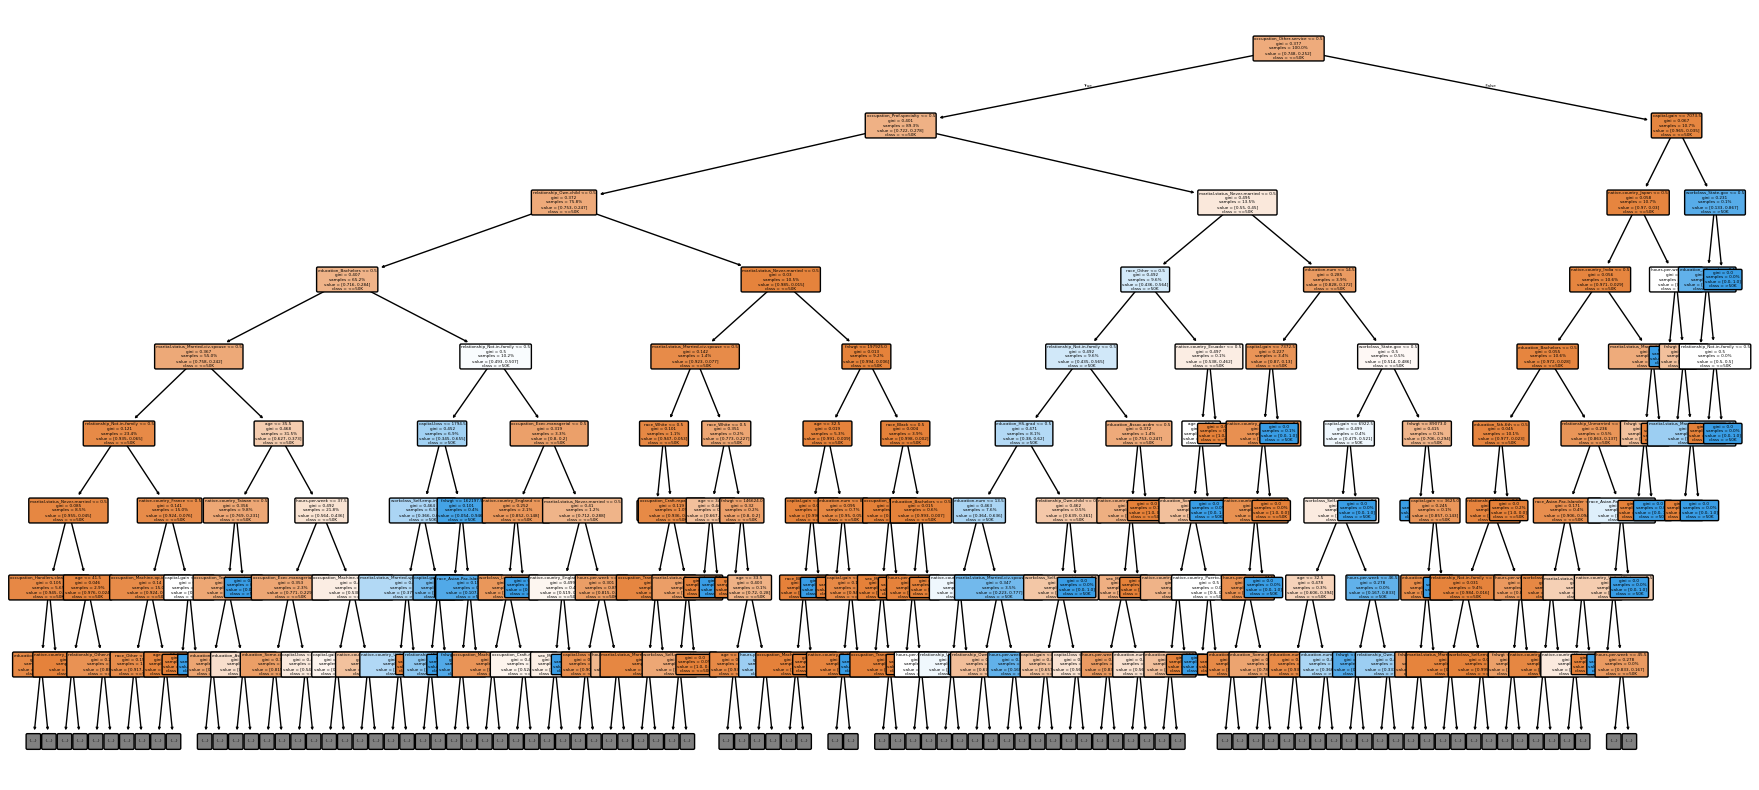

In [21]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree = rf_model.estimators_[0]

plt.figure(figsize=(22, 10))
plot_tree(
    tree,
    max_depth=8,
    feature_names=X.columns,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=3
)
plt.show()